In [1]:
%reload_ext autoreload
%autoreload 2

import pickle
import numpy as np
import healpy as hp
import json
from scipy import interpolate

from fpp.utils.validation import roc_finite_sample_band
from fpp.utils.multi_corner import multi_corner


import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../../nptf-test/production/matplotlibrc")

# Coverage

In [ ]:
! ls -lt ../outputs/fits

In [10]:
run_name = 'hmc_Dnmnew_Mbase'
z = pickle.load(open(f'../outputs/production/fits/{run_name}/p_nominal_actual_dict.p', 'rb'))
print(z.keys())

dict_keys(['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'n1_dsk', 'n2_dsk', 'n3_dsk', 'sb1_dsk', 'lambdas_dsk', 'Sps_gce', 'n1_gce', 'n2_gce', 'n3_gce', 'sb1_gce', 'lambdas_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'])


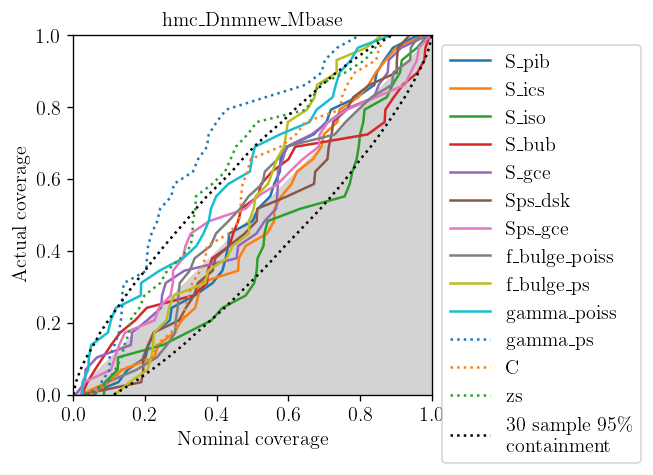

In [11]:
if 'pois' in run_name:
    labels = [
        'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
        'f_bulge_poiss', 'gamma_poiss',
    ]
else:
    labels = [
        'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
        'Sps_dsk', 'Sps_gce',
        'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
    ]

probs = [z[k] for k in labels]
ls_s = ['-'] * 10 + [':'] * 10

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label, ls in zip(probs, labels, ls_s):
    ax.plot(prob[0], prob[1], label=label, ls=ls)

n_run = len(probs[0][0])
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1, xlim=(0, 1), ylim=(0, 1))
ax.set(xlabel='Nominal coverage', ylabel='Actual coverage', title=run_name)

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()
# plt.savefig(f'plots/{run_name}.pdf')

# Corner

In [ ]:
config_dict = {
    '0' : ('../outputs/fits/hmc_D23new_p6v11_Mbase23fix/i0_n10000_ns0.p', 'b'),
    '1' : ('../outputs/fits/hmc_D23new_p6v11_Mbase23fixO/i0_n10000_ns0.p', 'g'),
    # '2' : ('../outputs/fits/svi_Dpois_Mpois_a0/i0_n50000_ns10000.p', 'r'),
}
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
for key, (path, color) in config_dict.items():
    run_name = path.split('/')[-2]
    losses_name = path[:-2] + '_losses.p'
    losses = pickle.load(open(losses_name, 'rb'))
    ax.plot(losses, color=color, lw=0.5)

ax.text(0.9, 0.9, f'final loss = {losses[-1]:.3f}', transform=ax.transAxes, ha='right', va='top', color=color)
ax.set(ylim=(losses[-1]-200, losses[-1]+200))
ax.set(xlabel='Iteration', ylabel='Loss');

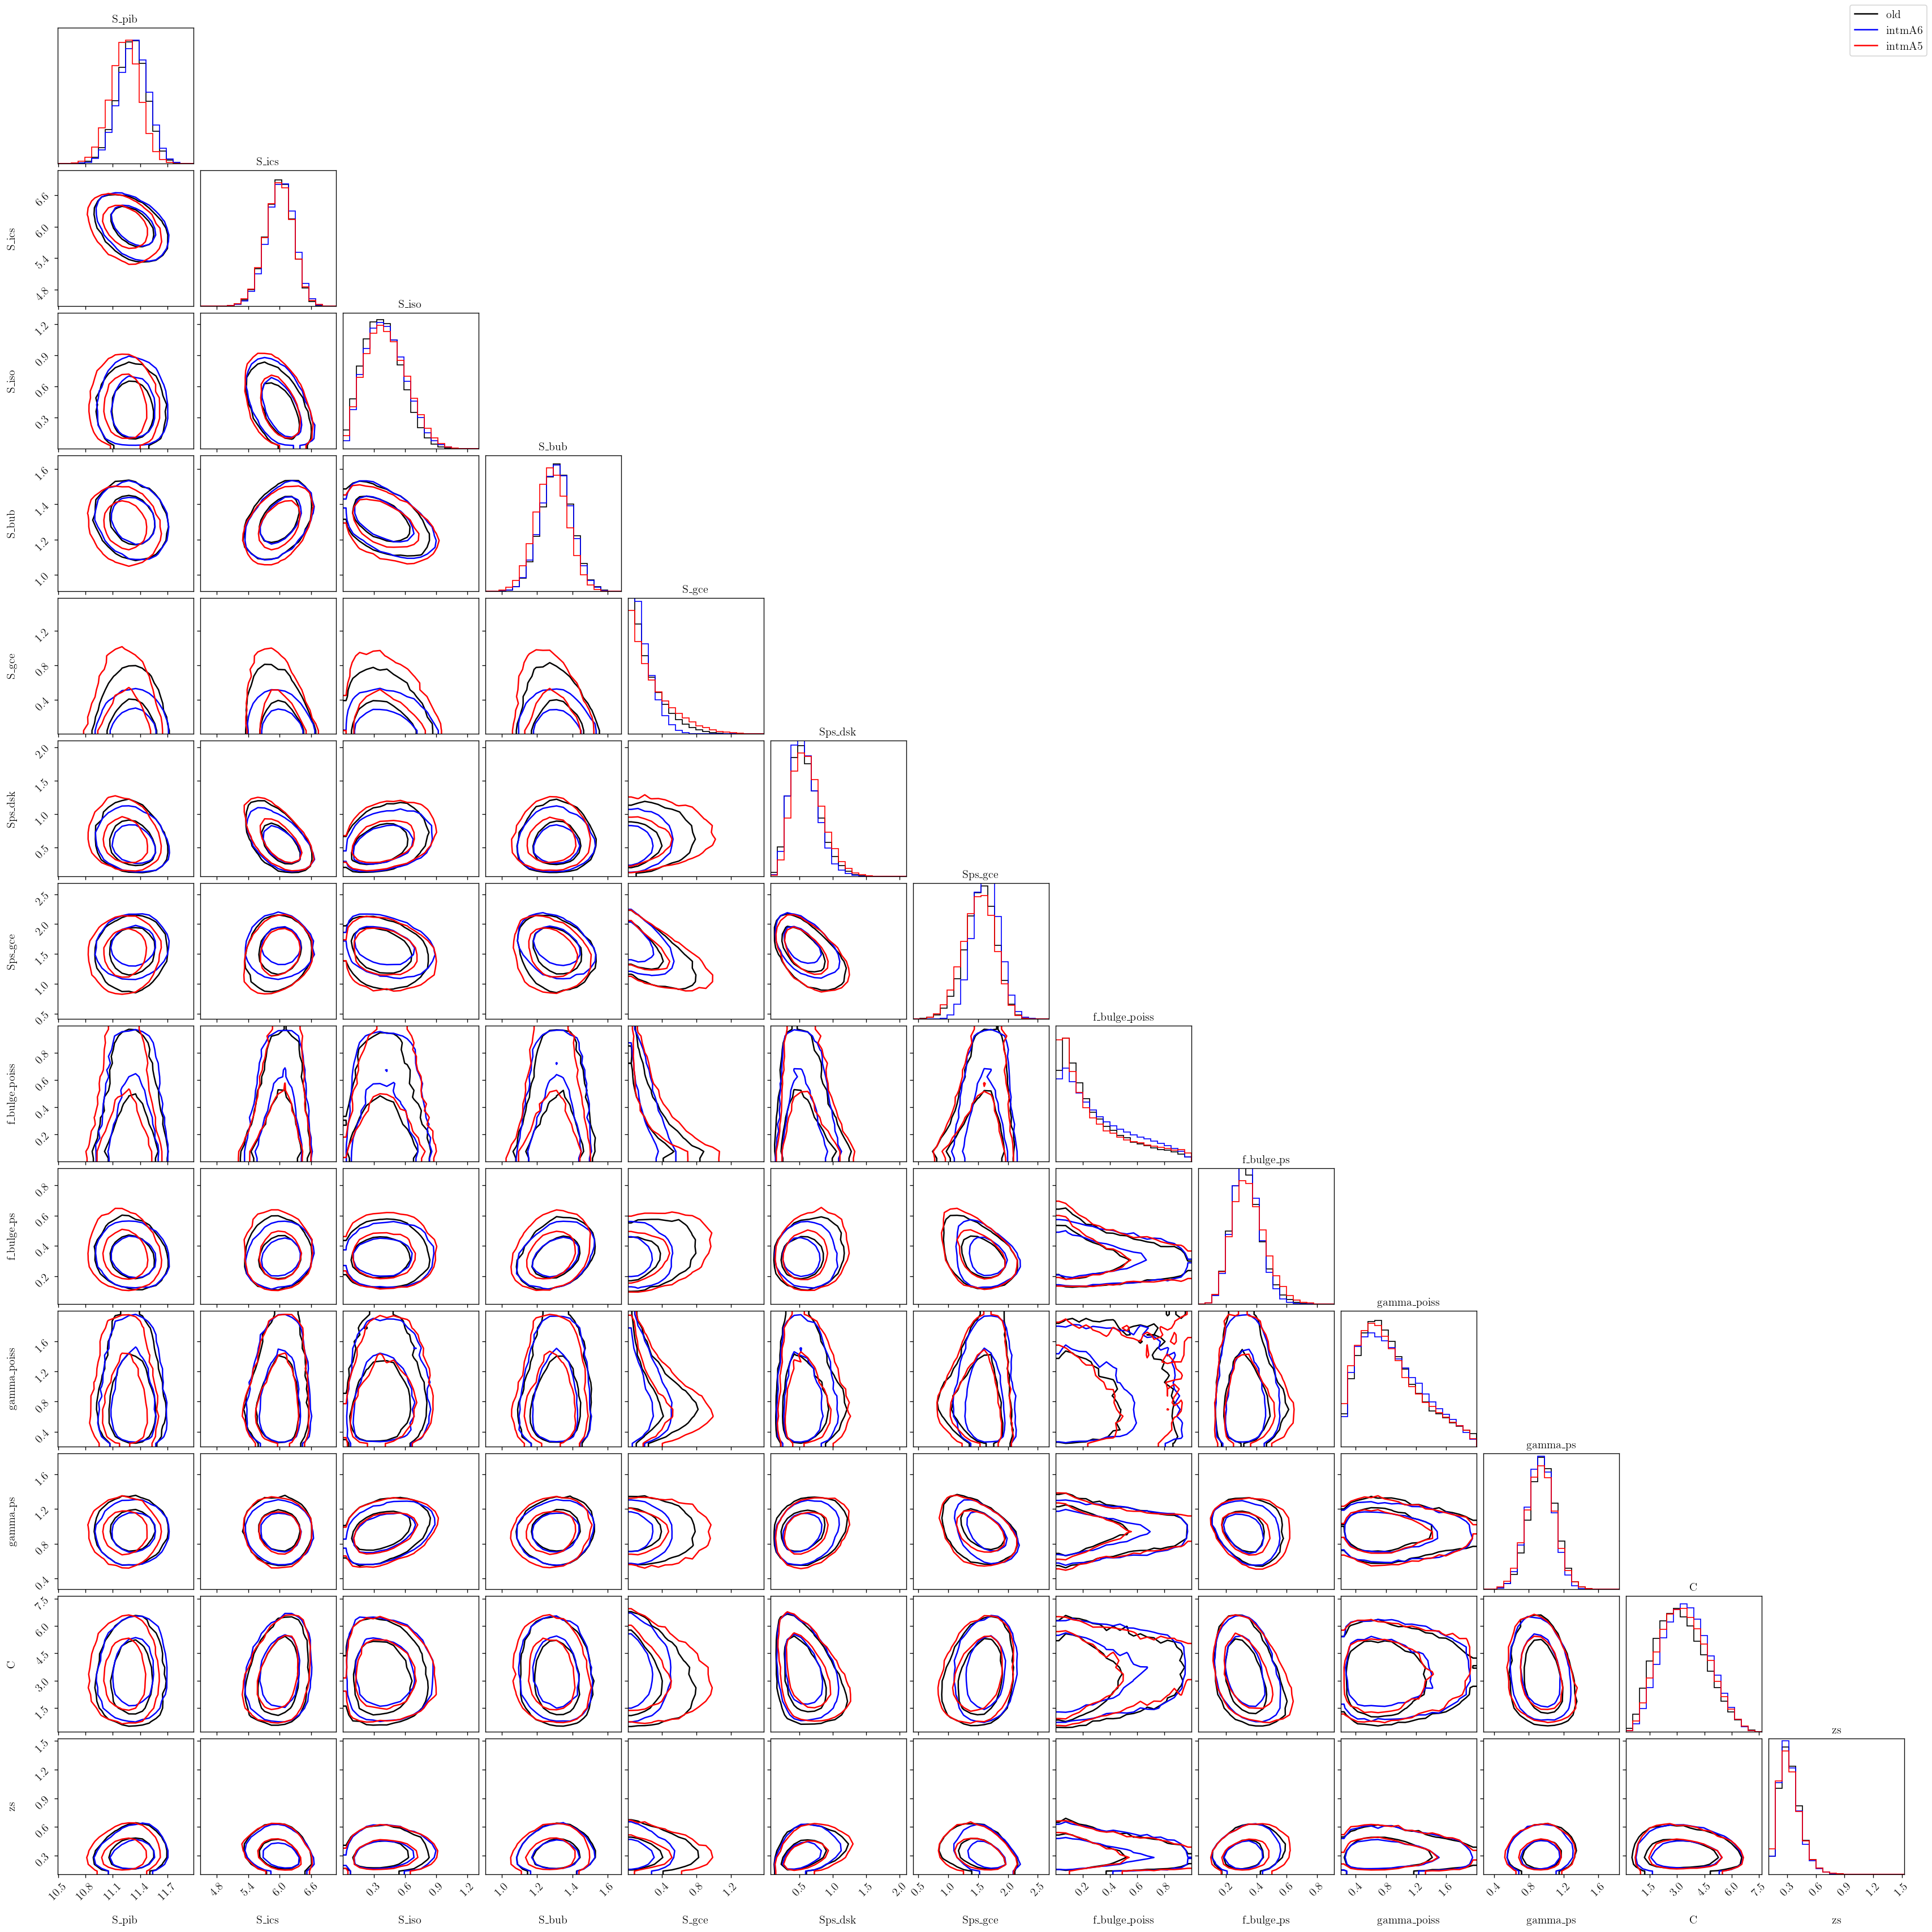

In [4]:
point_est = False
labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce', 'Sps_dsk', 'Sps_gce',
    'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
]
# config_dict = {
#     'old' : ('../outputs/production/fits/hmc_Dfermi_Mbase23fix/i0_n10000_ns0.p', 'k'),
#     'intmA6' : ('../outputs/fits/hmc_Dfermi_MintmA6/i0_n10000_ns0.p', 'b'),
#     'intmA5' : ('../outputs/fits/hmc_Dfermi_MintmA5/i0_n10000_ns0.p', 'r'),
# }
config_dict = {
    'old' : ('../outputs/production/fits/svi_Dfermi_Mbase23fix/i0_n50000_ns10000.p', 'k'),
    'intmA6' : ('../outputs/fits/svi_Dfermi_MintmA6/i0_n50000_ns10000.p', 'b'),
    'intmA5' : ('../outputs/fits/svi_Dfermi_MintmA5/i0_n50000_ns10000.p', 'r'),
}

s_in = {}
labels_dict = {}
colors_dict = {}
for key, (path, color) in config_dict.items():
    s = pickle.load(open(path, 'rb'))
    s_in[key] = {k: s[k] for k in labels}
    labels_dict[key] = key
    colors_dict[key] = color

t_in = {k: truth_dict[k] for k in labels} if point_est else None

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)

# Temp view data

In [3]:
from fpp.models.np_model import NPModel
m = NPModel()

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/analysis/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [7]:
z = np.load("../outputs/simulations/testdsk.npy")
z2 = np.load("../outputs/simulations/testdsk2.npy")
z3 = np.load("../outputs/simulations/testdsk3.npy")

In [20]:
t = np.array(m.dsk_temp_gen.get_template(zs=0.5, C=2.5))

In [10]:
m.nm

array([ True,  True,  True, ...,  True,  True,  True])

In [21]:
t /= np.mean(t[~m.nm])
t *= 1.3

In [22]:
t[m.mask_roi] = 0
np.mean(t[~m.nm])

0.9684323878040245

In [ ]:
print(np.mean( z[:,~m.nm]))
print(np.mean(z2[:,~m.nm]))
print(np.mean(z3[:,~m.nm]))

0.9720502
0.9753389
1.3088555


In [ ]:
hp.cartview(m.mask_roi, latra=[-25, 25], lonra=[-25, 25])

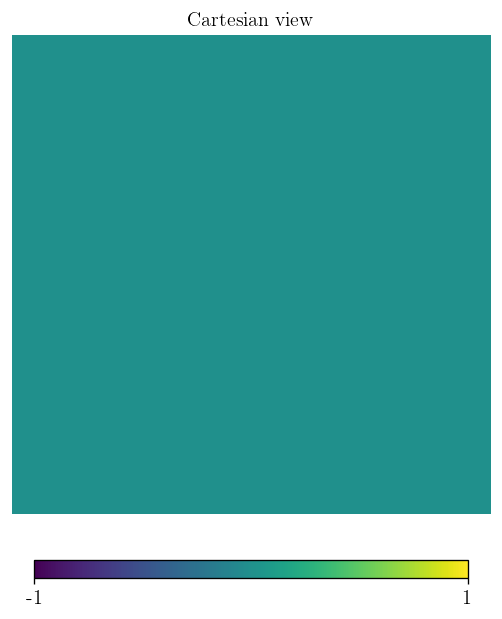

In [9]:
z2[0][~m.mask_roi] = 0
hp.cartview(z2[0], latra=[-25, 25], lonra=[-25, 25])

# Archive

In [ ]:
def regularize_sample(s):
    if 'f_bulge_poiss' in s:
        return s
    s['S_pib'] = s['S_pib_0'] + s['S_pib_1'] + s['S_pib_2']
    s['theta_pib_ModelO'] = s['S_pib_0'] / s['S_pib']
    s['theta_pib_ModelA'] = s['S_pib_1'] / s['S_pib']
    s['theta_pib_ModelF'] = s['S_pib_2'] / s['S_pib']
    s['S_ics'] = s['S_ics_0'] + s['S_ics_1'] + s['S_ics_2']
    s['theta_ics_ModelO'] = s['S_ics_0'] / s['S_ics']
    s['theta_ics_ModelA'] = s['S_ics_1'] / s['S_ics']
    s['theta_ics_ModelF'] = s['S_ics_2'] / s['S_ics']
    s['S_gce_blg'] = s['S_gce_blg_0'] + s['S_gce_blg_1'] + s['S_gce_blg_2'] + s['S_gce_blg_3'] + s['S_gce_blg_4']
    s['S_gce'] = s['S_gce_blg'] + s['S_gce_nfw']
    s['f_bulge_poiss'] = s['S_gce_blg'] / s['S_gce']
    for i, k in enumerate(["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"]):
        s[f'theta_poiss_{k}'] = s[f'S_gce_blg_{i}'] / s['S_gce_blg']
    s['Sps_gce_blg'] = s['Sps_gce_blg_0'] + s['Sps_gce_blg_1'] + s['Sps_gce_blg_2'] + s['Sps_gce_blg_3'] + s['Sps_gce_blg_4']
    s['Sps_gce'] = s['Sps_gce_blg'] + s['Sps_gce_nfw']
    s['f_bulge_ps'] = s['Sps_gce_blg'] / s['Sps_gce']
    for i, k in enumerate(["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"]):
        s[f'theta_ps_{k}'] = s[f'Sps_gce_blg_{i}'] / s['Sps_gce_blg']
    return s

# Marginal posterior

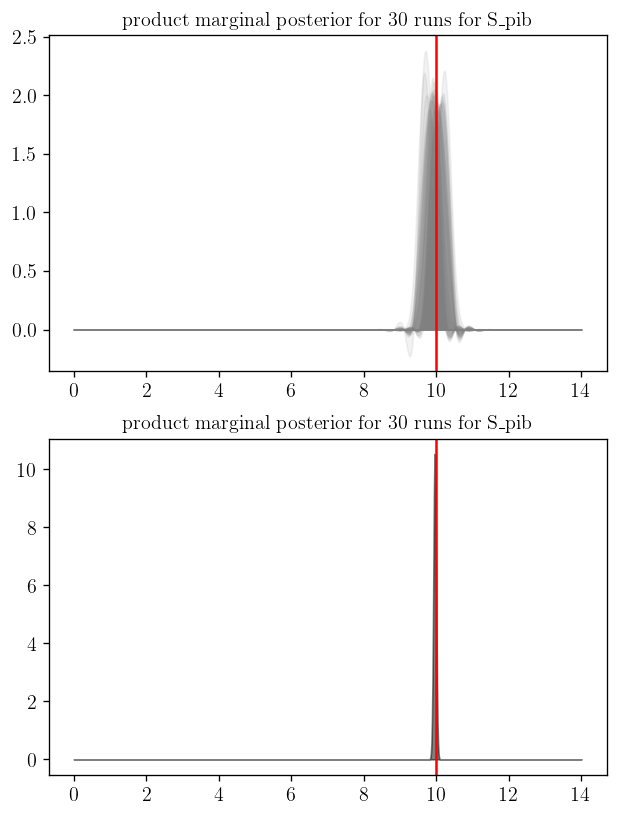

In [11]:
run_name = 'pthmc_Dbase23fix_deltapsf_Mbase23fix_deltapsf'
# run_name = 'hmc_Dbase230927new_Mbase230927'

truth_dict = json.load(open(f'truth_dict_base230927.json', 'r'))
k = 'S_pib'
n_run = 30

prior_dict = json.load(open(f'prior_dict_base230927.json', 'r'))
n_bins = 50
n_bins_sr = 1000
bin_edges = np.linspace(*prior_dict[k], n_bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_centers_sr = np.linspace(*prior_dict[k], n_bins_sr)

fig, axs = plt.subplots(2, 1, figsize=(6, 8))

pdf_tot = np.ones(n_bins_sr)
for i, x in enumerate(range(n_run)):
    s = pickle.load(open(f'../outputs/fit/{run_name}/i{x}_n10000_ns2000.p', 'rb'))
    pdf, _ = np.histogram(s[k], bins=bin_edges)
    pdf_sr = interpolate.CubicSpline(bin_centers, pdf, extrapolate=True)(bin_centers_sr)
    pdf_sr /= np.trapz(pdf_sr, bin_centers_sr)
    axs[0].fill_between(bin_centers_sr, pdf_sr, 0, color='gray', alpha=0.1)

    pdf_tot *= pdf_sr
    pdf_tot /= np.trapz(pdf_tot, bin_centers_sr)

axs[1].fill_between(bin_centers_sr, pdf_tot, 0, color='k', alpha=0.5)

axs[0].axvline(truth_dict[k], color='red')
axs[0].set(title=f'product marginal posterior for {n_run} runs for {k}')
axs[1].axvline(truth_dict[k], color='red')
axs[1].set(title=f'product marginal posterior for {n_run} runs for {k}');

# Compare truth

In [5]:
truth_dict_s = [
    json.load(open('truth_dict_base230927.json', 'r')),
    json.load(open('truth_dict_psc.json', 'r')),
    json.load(open('truth_dict_base230927new.json', 'r'))
]
name_s = ['base', 'psc', 'base_new']
prior_dict = json.load(open('prior_dict_base230927.json', 'r'))

In [ ]:
print(f'            '+' '.join([f'{n:>10}' for n in name_s])+'    prior')
for k in truth_dict_s[0].keys():
    if isinstance(truth_dict_s[0][k], list):
        str_s = [f'{str(truth_dict_s[0][k]):>10}' for i in range(len(truth_dict_s))]
    elif k.starts_with('A'):
        continue
    else:
        str_s = [f'{truth_dict_s[i][k]:>10.1f}' for i in range(len(truth_dict_s))]
    print(f'{k:12}'+' '.join(str_s)+    f'    {prior_dict[k]}')

In [15]:
from itertools import cycle

def show_interval_and_values(ax, y, interval, values, normalize=False):
    cc = cycle(plt.rcParams['axes.prop_cycle'])
    if normalize:
        values = [(v - interval[0]) / (interval[1] - interval[0]) for v in values]
        interval = [0, 1]
    interval_style = dict(color='k', lw=2)
    ax.plot(interval, [y, y], **interval_style)
    ax.plot([interval[0], interval[0]], [y-0.1, y+0.1], **interval_style)
    ax.plot([interval[1], interval[1]], [y-0.1, y+0.1], **interval_style)
    for v in values:
        ax.plot(v, y, marker='o', **next(cc))

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(3, 8))
ax = axs
y = 0
for k in truth_dict_new.keys():
    if not isinstance(truth_dict_old[k], list):
        show_interval_and_values(ax, y, prior_dict[k], [truth_dict_old[k], truth_dict_new[k]], normalize=True)
        ax.text(1.2, y, k, ha='left', va='center')
        y -= 1

# Compare LL

In [11]:
from models.np_model import NPModel
m = NPModel(data=np.zeros(mask_norm.shape[0]))

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of pixels in ROI: 6839
Using psf: king
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/production/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 0.0


In [24]:
import jax.numpy as jnp
from models.scd import dnds
import jax
from likelihoods.npll_jax import log_like_np
from einops import repeat

In [21]:
def model(self, data, vd):
    
    # Get mixed pib template
    theta_pib = jnp.array(vd['theta_pib'])
    temp_pib = jnp.sum(theta_pib[:, None] * self.pib, 0)

    # Get mixed ics template
    theta_ics = jnp.array(vd['theta_ics'])
    temp_ics = jnp.sum(theta_ics[:, None] * self.ics, 0)

    S_gce = vd['S_gce']
        
    temps = [self.temp_iso, self.temp_bub, self.temp_psc, temp_pib, temp_ics]
    temp_labels = ["iso", "bub", "psc", "pib", "ics"]
            
    mu = jnp.zeros_like(data)
    
    for temp, temp_label in zip(temps, temp_labels):
        
        S_temp = vd["S_{}".format(temp_label)]
        
        if temp_label in ["pib"]:
            
            temp_pib_mod = jnp.zeros_like(data)
            for ii in range(len(self.Ylm_temps)):
                Alm = 0.
                temp_pib_mod += Alm * self.Ylm_temps[ii]
            
            temp_pib_mod = (1. + temp_pib_mod) * temp
            
            A_temp = S_temp / jnp.mean(temp_pib_mod[~self.normalization_mask])
            mu += A_temp * temp_pib_mod  
        else:
            A_temp = S_temp / jnp.mean(temp[~self.normalization_mask])
            mu += A_temp * temp     
                                        
    gamma_ps = vd["gamma_ps"]
    gamma_poiss = vd["gamma_poiss"]

    temp_gce_nfw_ps = self.nfw_template.get_NFW2_template(gamma=gamma_ps) if self.non_poissonian else None
    temp_gce_nfw_poiss = self.nfw_template.get_NFW2_template(gamma=gamma_poiss)
        

    zs = vd["zs"]
    C = vd["C"]
    temp_dsk = self.disk_template.get_template(zs=zs, C=C)
            
    f_bulge_ps = vd["f_bulge_ps"]
    f_bulge_poiss = vd["f_bulge_poiss"]
    
    theta_bulge_poiss = jnp.array(vd["theta_bulge_poiss"])
    temp_bulge = jnp.sum(theta_bulge_poiss[:, None] * self.bulge_templates, 0)
    
    # Normalize to same mean
    A_gce_nfw = S_gce / jnp.mean(temp_gce_nfw_poiss[~self.normalization_mask])
    A_gce_bulge = S_gce / jnp.mean(temp_bulge[~self.normalization_mask])
    temp_gce_poiss = (1 - f_bulge_poiss) * A_gce_nfw * temp_gce_nfw_poiss \
                        + f_bulge_poiss * A_gce_bulge * temp_bulge
    
    A_gce = S_gce / jnp.mean(temp_gce_poiss[~self.normalization_mask])
    mu += A_gce * temp_gce_poiss
    
    if self.non_poissonian:
        # Get mixed bulge template
        theta_bulge_ps = jnp.array(vd["theta_bulge_ps"])
        temp_bulge = jnp.sum(theta_bulge_ps[:, None] * self.bulge_templates, 0)

        # Normalize to same mean
        A_gce_nfw = 1 / jnp.mean(temp_gce_nfw_ps[~self.normalization_mask])
        A_gce_bulge = 1 / jnp.mean(temp_bulge[~self.normalization_mask])

        # Get hybrid template
        temp_gce_ps = (1 - f_bulge_ps) * A_gce_nfw * temp_gce_nfw_ps + f_bulge_ps * A_gce_bulge * temp_bulge

        npt_compressed = jnp.array([temp_gce_ps, temp_dsk])

        theta = []    

        for ips, ps in enumerate(["gce", "dsk"]):

            Sps = vd["Sps_{}".format(ps)]

            n1 = vd["n1_{}".format(ps)]
            n2 = vd["n2_{}".format(ps)]
            n3 = vd["n3_{}".format(ps)]
            sb1 = vd["sb1_{}".format(ps)]
            lambda_s = vd["lambdas_{}".format(ps)]

            theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])

            s_ary = jnp.logspace(-1., 2., 1000)
            dnds_ary = dnds(s_ary, theta_tmp)

            A = Sps / jnp.mean(npt_compressed[ips][~self.normalization_mask] * jnp.trapz(s_ary * dnds_ary, s_ary))

            theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])

        theta = jnp.array(theta)
            
    # Pad the last exposure region so that all are the same size
    exp_lens = [len(self.expreg_indices[i]) for i in range(len(self.expreg_indices))]
    n_pad = exp_lens[0] - exp_lens[-1]
    
    expreg_indices = jnp.zeros_like(self.expreg_indices)
    expreg_indices = expreg_indices.at[:-1].set(self.expreg_indices[:-1])
    expreg_indices = expreg_indices.at[-1].set(jnp.pad(self.expreg_indices[-1], (0, n_pad)))

    log_like_np_exp_vmapped = jax.vmap(log_like_np, in_axes=(0, 0, 1, 0, None, None, None, None))
            
    # Get relevant arrays for different exposure regions
    mu_batch = mu[~self.mask_roi][jnp.array(expreg_indices)]
    if self.non_poissonian:
        npt_compressed_batch = npt_compressed[:, ~self.mask_roi][:, jnp.array(expreg_indices)]
    data_batch = data[~self.mask_roi][jnp.array(expreg_indices)]
    
    exposure_multiplier = self.exposure_means_list / self.exposure_mean
    
    # Scale non-Poissonian parameters (norm divided by exposure ratio, breaks multiplied)
    if self.non_poissonian:
        theta = repeat(theta, "n_ps n_param -> n_exp n_ps n_param", n_exp=len(expreg_indices))
        theta = theta.at[:, :, 0].set(theta[:, :, 0] / exposure_multiplier[:, None])
        theta = theta.at[:, :, -1].set(theta[:, :, -1] * exposure_multiplier[:, None])
        theta = theta.at[:, :, -2].set(theta[:, :, -2] * exposure_multiplier[:, None])
    
    log_like_exp = log_like_np_exp_vmapped(theta, mu_batch, npt_compressed_batch, data_batch, self.f_ary, self.df_rho_ary, self.k_max, len(expreg_indices[0]))
    log_like = jnp.sum(log_like_exp)
    return log_like

In [53]:
vd = json.load(open('truth_dict_base230927.json', 'r'))
data = jnp.array(np.load('../outputs/sims/gpsfix_s1k_n100.npy'), dtype=jnp.int32)

In [54]:
a0 = []
vd = json.load(open('truth_dict_base230927.json', 'r'))
for i in range(30):
    m.k_max = int(jnp.max(data[i]))
    a0.append(model(m, data[i], vd))

In [55]:
a1 = []
vd['C'] = 3.870763450
for i in range(30):
    m.k_max = int(jnp.max(data[i]))
    a1.append(model(m, data[i], vd))

In [56]:
for i in range(30):
    print(a0[i], a1[i], a0[i] - a1[i])

-19843.637537150436 -19846.264351272817 2.6268141223808925
-19650.597644330686 -19651.65761113611 1.0599668054237554
-19860.243499191456 -19865.52415644849 5.280657257033454
-19750.742546351103 -19750.59348502507 -0.14906132603209699
-19762.374111168057 -19765.563272415315 3.189161247257289
-19859.641161732092 -19861.8207103729 2.179548640808207
-19710.993544656925 -19708.641030891344 -2.3525137655815342
-19852.784644681997 -19852.576427725053 -0.20821695694394293
-19848.96276069127 -19856.218207380727 7.25544668945804
-19876.413951559105 -19882.3184395232 5.904487964093278
-19818.74510348549 -19820.29524786496 1.5501443794710212
-19772.16058018559 -19774.20364814697 2.043067961378256
-19854.592420543744 -19859.03740689024 4.444986346494261
-19702.20744072573 -19700.669824074314 -1.5376166514179204
-19710.47911210653 -19704.13134309036 -6.347769016167149
-19826.5426405748 -19829.208793138238 2.6661525634372083
-19757.390431980544 -19761.413397290387 4.02296530984313
-19863.946890273794

In [ ]:
for i in range(30):
    print(a0[i], a1[i], a0[i] - a1[i])

-19843.637537150436 -19853.220846365926 9.583309215489862
-19650.597644330686 -19661.36299001868 10.765345687992522
-19860.243499191456 -19859.60373245788 -0.6397667335768347
-19750.742546351103 -19756.001456338803 5.258909987700463
-19762.374111168057 -19776.540630175565 14.166519007507304
-19859.641161732092 -19863.970370786694 4.329209054601961
-19710.993544656925 -19717.226838077007 6.233293420082191
-19852.784644681997 -19855.741835408633 2.957190726636327
-19848.96276069127 -19865.829132283965 16.86637159269594
-19876.413951559105 -19880.797328102053 4.383376542948099
-19818.74510348549 -19817.428471611158 -1.316631874331506
-19772.16058018559 -19783.032732938667 10.87215275307608
-19854.592420543744 -19861.525181433157 6.932760889412748
-19702.20744072573 -19711.432718776905 9.225278051173518
-19710.47911210653 -19720.26534217719 9.786230070661986
-19826.5426405748 -19827.57414665581 1.0315060810098657
-19757.390431980544 -19764.163620394917 6.773188414372271
-19863.946890273794

In [42]:
s = pickle.load(open(f'../outputs/fit/{run_name}/i0_n10000_ns0.p', 'rb'))
s['theta_bulge_poiss'].shape

(10000, 5)

In [45]:
run_name = 'hmc_Dgpsfix_s1k_Mkmaxfix_s1k'
s = pickle.load(open(f'../outputs/fit/{run_name}/i0_n10000_ns0.p', 'rb'))
mean_dict = {k: [np.mean(s[k], axis=0)] for k in s.keys()}
for i, x in enumerate(range(30)):
    s = pickle.load(open(f'../outputs/fit/{run_name}/i{x}_n10000_ns0.p', 'rb'))
    for k in s.keys():
        mean_dict[k].append(np.mean(s[k], axis=0))
mean_dict = {k: np.mean(v, axis=0) for k, v in mean_dict.items()}
mean_dict

{'Alm_0': 0.0014993741996418767,
 'Alm_1': 0.0017828545217713173,
 'Alm_2': 0.0027355607751966033,
 'Alm_3': 0.00027808695057313803,
 'Alm_4': 0.0006457696269420098,
 'Alm_5': 0.0009113529701641291,
 'C': 3.8707634506063795,
 'S_bub': 0.20406567502000744,
 'S_gce': 0.848365762483275,
 'S_ics': 6.303625085488799,
 'S_iso': 0.36336581309954646,
 'S_pib': 9.939847552252827,
 'S_psc': 1.9738702026442192,
 'Sps_dsk': 1.6729062812315536,
 'Sps_gce': 0.9857193313673714,
 'f_bulge_poiss': 0.3809464312009202,
 'f_bulge_ps': 0.4069512007968499,
 'gamma_poiss': 1.2172260901265983,
 'gamma_ps': 1.2113420671820754,
 'lambdas_dsk': 0.49003728371872357,
 'lambdas_gce': 0.4611669753248206,
 'n1_dsk': 5.099023945383252,
 'n1_gce': 5.098210301409485,
 'n2_dsk': 1.2498883396148124,
 'n2_gce': 1.2826096520414179,
 'n3_dsk': -5.499987635736554,
 'n3_gce': -5.4913560890285975,
 'sb1_dsk': 10.185140208675483,
 'sb1_gce': 11.452580361442715,
 'theta_bulge_poiss': array([0.25956766, 0.26505486, 0.10013265, 0.2

In [35]:
vd

{'theta_pib': [1.0, 0.0, 0.0],
 'theta_ics': [1.0, 0.0, 0.0],
 'S_iso': 0.3,
 'S_bub': 0.2,
 'S_psc': 0.5,
 'S_pib': 10.0,
 'S_ics': 6.0,
 'Sps_dsk': 1.3,
 'zs': 0.5,
 'C': 2.5,
 'S_gce': 1.0,
 'gamma_poiss': 0.9,
 'f_bulge_poiss': 0.2,
 'Sps_gce': 1.5,
 'gamma_ps': 1.2,
 'f_bulge_ps': 0.3,
 'theta_bulge_poiss': [1.0, 0.0, 0.0, 0.0, 0.0],
 'theta_bulge_ps': [0.0, 1.0, 0.0, 0.0, 0.0],
 'n1_dsk': 5.0,
 'n2_dsk': 1.3,
 'n3_dsk': -5.4,
 'sb1_dsk': 11.0,
 'lambdas_dsk': 0.4,
 'n1_gce': 5.5,
 'n2_gce': 1.5,
 'n3_gce': -5.5,
 'sb1_gce': 7.6,
 'lambdas_gce': 0.3,
 'Alm_0': 0.0,
 'Alm_1': 0.0,
 'Alm_2': 0.0,
 'Alm_3': 0.0,
 'Alm_4': 0.0,
 'Alm_5': 0.0}